In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
import plotly.express as px

sys.path.append(r"D:/Football Project/src")

from feature_lists_v1 import (
    misc_features,
    fw_features,
    availability_features
)

In [3]:
df=pd.read_csv("../../data/processed/top5leagues_processed_2025.csv")

In [4]:
df.columns

Index(['league', 'season', 'team', 'player', 'nation', 'pos', 'age', 'born',
       'Playing Time_MP', 'Playing Time_Starts', 'Playing Time_Min',
       'Playing Time_90s', 'Performance_Gls', 'Performance_Ast',
       'Performance_G+A', 'Performance_G-PK', 'Performance_PK',
       'Performance_PKatt', 'Performance_CrdY', 'Performance_CrdR',
       'Per 90 Minutes_Gls', 'Per 90 Minutes_Ast', 'Per 90 Minutes_G+A',
       'Per 90 Minutes_G-PK', 'Per 90 Minutes_G+A-PK', '90s', 'Standard_Gls',
       'Standard_Sh', 'Standard_SoT', 'Standard_SoT%', 'Standard_Sh/90',
       'Standard_SoT/90', 'Standard_G/Sh', 'Standard_G/SoT', 'Standard_PK',
       'Standard_PKatt', 'Starts_Starts', 'Starts_Mn/Start', 'Starts_Compl',
       'Subs_Subs', 'Subs_Mn/Sub', 'Subs_unSub', 'Team Success_PPM',
       'Team Success_onG', 'Team Success_onGA', 'Team Success_+/-',
       'Team Success_+/-90', 'Team Success_On-Off', 'Performance_GA',
       'Performance_GA90', 'Performance_SoTA', 'Performance_Saves',
     

In [5]:
strikers = df[df["pos"].str.contains("FW", na=False)].copy()
strikers = strikers[strikers["Playing Time_Min"] >= 500].copy()
print(len(strikers))

491


# Only Considering Players who play a Forward Role and have played meaningful minutes #

In [6]:
strikers.head()

,league,season,team,player,nation,pos,age,born,Playing Time_MP,Playing Time_Starts,...,xa_per_key_pass,assist_minus_xa,buildup_share,finishing_share,xg_per90,xa_per90,shots_per90,key_passes_per90,xg_chain_per90,xg_buildup_per90
1,ENG-Premier League,2526,Arsenal,Bukayo Saka,ENG,"FW,MF",23,2001.0,31,25,...,0.137948,-3.552798,0.420553,0.455261,0.352275,0.346267,2.874494,2.510121,0.773788,0.325419
6,ENG-Premier League,2526,Arsenal,Eberechi Eze,ENG,"MF,FW",27,1998.0,32,21,...,0.154913,-0.633517,0.393402,0.464220,0.239177,0.131021,3.134328,0.845771,0.515223,0.202690
10,ENG-Premier League,2526,Arsenal,Gabriel Martinelli,BRA,"FW,MF",24,2001.0,30,11,...,0.197629,1.430829,0.359815,0.534463,0.446422,0.214098,2.416667,1.083333,0.835272,0.300543
12,ENG-Premier League,2526,Arsenal,Kai Havertz,GER,"FW,MF",26,1999.0,12,7,...,0.132453,1.543016,0.166219,1.082599,0.753155,0.224151,2.769231,1.692308,0.695692,0.115637
14,ENG-Premier League,2526,Arsenal,Leandro Trossard,BEL,"FW,MF",30,1994.0,31,21,...,0.138556,1.011992,0.365483,0.497558,0.304197,0.224685,2.387387,1.621622,0.611380,0.223449


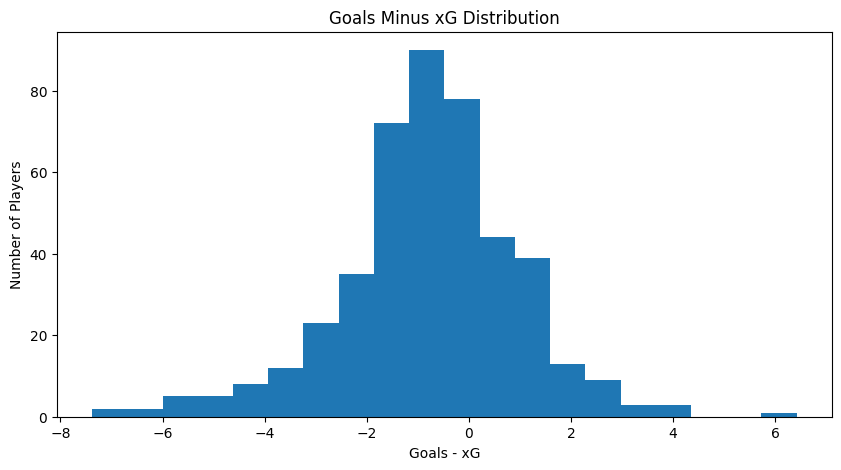

In [7]:
plt.figure(figsize=(10, 5))

plt.hist(
    strikers["goals_minus_xg"],
    bins=20
)

plt.title("Goals Minus xG Distribution")
plt.xlabel("Goals - xG")
plt.ylabel("Number of Players")

plt.show()

In [8]:
strikers.sort_values(
    "goals_minus_xg",
    ascending=0
)[
    ["player", "team", "Performance_Gls", "xg", "goals_minus_xg"]
].head(5)

,player,team,Performance_Gls,xg,goals_minus_xg
1762,Harry Kane,Bayern Munich,36,29.579986,6.420014
65,Eli Junior Kroupi,Bournemouth,13,8.849122,4.150878
2335,Martin Baturina,Como,6,1.901092,4.098908
2098,Yan Diomandé,RB Leipzig,12,8.030208,3.969792
1622,Ousmane Dembélé,Paris Saint-Germain,10,6.604902,3.395098


In [9]:
strikers.sort_values(
    "assist_minus_xa",
    ascending=1
)[
    ["player", "team", "Performance_Ast", "xa", "assist_minus_xa"]
].head(5)

,player,team,Performance_Ast,xa,assist_minus_xa
222,Yeremi Pino,Crystal Palace,2,8.502094,-6.502094
2235,Charles De Ketelaere,Atalanta,5,10.652647,-5.652647
2525,Kenan Yıldız,Juventus,6,10.820393,-4.820393
1911,Jean-Luc Dompé,Hamburger SV,0,4.045239,-4.045239
1603,Bradley Barcola,Paris Saint-Germain,1,4.783319,-3.783319


In [10]:
fig = px.scatter(
    strikers[strikers["Performance_Gls"] >= 8].copy(), 
    x='Playing Time_Min', 
    y='goals_minus_xg',
    hover_name='player',         
    hover_data=['team', 'pos', 'Standard_Gls', 'xg'], 
    title='Striker Finishing Performance',
    labels={
        'Playing Time_Min': 'Minutes Played',
        'goals_minus_xg': 'Goals Minus xG'
    },
    template='plotly_white',               
    width=1000, 
    height=600
)

fig.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="xG Baseline")

fig.update_traces(marker=dict(size=10, opacity=0.8, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

In [11]:
max_val = max(strikers['xg_per_shot'].max(), strikers['shot_conversion'].max()) + 0.05
fig = px.scatter(
    strikers[strikers["Performance_Gls"] >= 8].copy(), 
    x='xg_per_shot', 
    y='shot_conversion',
    hover_name='player',         
    hover_data=['team', 'Playing Time_Min', 'Standard_Gls', 'xg'], 
    title='Striker Finishing Performance',
    labels={
        'xg_per_shot': 'xg per shot',
        'shot_conversion': 'shot conversion'
    },
    template='plotly_white',               
    width=1000, 
    height=600
)

fig.add_shape(type='line',x0=0,y0=0,x1=max_val,y1=max_val, line=dict(color="red", width=2, dash="dash"))

fig.update_traces(marker=dict(size=10, opacity=0.8, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

In [18]:
max_val = max(strikers['Standard_Gls'].max(), strikers['xg'].max()) + 0.05
fig = px.scatter(
    strikers[strikers["Performance_Gls"] >= 5].copy(), 
    y='Standard_Gls', 
    x='xg',
    hover_name='player',         
    hover_data=['team', 'Playing Time_Min', 'Standard_Gls', 'xg'], 
    title='Striker Finishing Performance',
    labels={
        'xg': 'xg',
        'Standard_Gls': 'goals'
    },
    template='plotly_white',               
    width=1000, 
    height=600
)

fig.add_shape(type='line',x0=0,y0=0,x1=max_val,y1=max_val, line=dict(color="red", width=2, dash="dash"))

fig.update_traces(marker=dict(size=10, opacity=0.8, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

In [19]:
def scatter_plot(
    df,
    x,
    y,
    min_goals=None,
    goals_col="Standard_Gls",
    hover_cols=None,
    title=None,
    width=1000,
    height=600,
    reference_line=False
):
    data = df.copy()

    if min_goals is not None:
        data = data[data[goals_col] >= min_goals]

    if hover_cols is None:
        hover_cols = []

    fig = px.scatter(
        data,
        x=x,
        y=y,
        hover_name="player",
        hover_data=hover_cols,
        title=title if title else f"{y} vs {x}",
        template="plotly_white",
        width=width,
        height=height
    )

    if reference_line:
        max_val = max(data[x].max(), data[y].max())

        fig.add_shape(
            type="line",
            x0=0,
            y0=0,
            x1=max_val,
            y1=max_val,
            line=dict(
                color="red",
                width=2,
                dash="dash"
            )
        )

    fig.update_traces(
        marker=dict(
            size=10,
            opacity=0.8,
            line=dict(width=1, color="DarkSlateGrey")
        )
    )

    fig.show()

In [24]:
scatter_plot(
    strikers,
    x="xg_per90",
    y="xg_chain_per90",
    min_goals=5,
    hover_cols=["team"]
)

In [25]:
scatter_plot(
    strikers,
    x="xg_per90",
    y="xa_per90",
    hover_cols=["team",'Playing Time_Min']
)

In [ ]:
scatter_plot(
    strikers,
    x="shots_per90",
    y="xg_per90",
    hover_cols=["team"]
)

In [34]:
scatter_plot(
    strikers,
    x="finishing_share",
    y="xg_buildup_per90",
    hover_cols=["team"]
)

## Harry Kane seems to be the best performing Forward in terms of Goals in 2025-26 ##

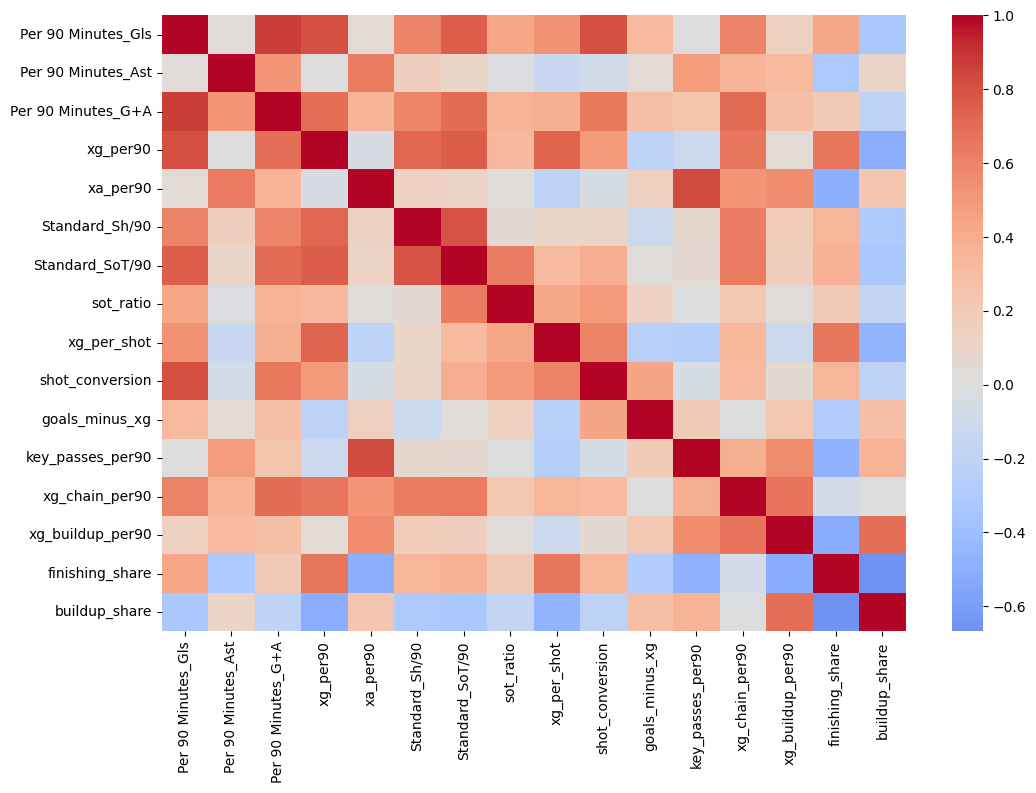

In [31]:
corr = strikers[fw_features].corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.show()

In [ ]:
striker_features_final = [
    "xg_per90",
    "xa_per90",
    "Standard_Sh/90",
    "Standard_SoT/90",
    "shot_conversion",
    "goals_minus_xg",
    "key_passes_per90",
    "xg_chain_per90",
    "xg_buildup_per90",
    "finishing_share"
]

In [35]:
strikers_model = strikers[
    [
        "league",
        "season",
        "team",
        "player",
        "nation",
        "age",

        "xg_per90",
        "xa_per90",
        "Standard_Sh/90",
        "Standard_SoT/90",
        "shot_conversion",
        "goals_minus_xg",
        "key_passes_per90",
        "xg_chain_per90",
        "xg_buildup_per90",
        "finishing_share"
    ]
].copy()

In [ ]:
#strikers_model.to_csv("../../data/processed/strikers_top5leagues_features.csv",index=False)